Usando o exemplo 499

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install nltk
%pip install lime

%pip install shap

%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#importando pacotes e bibliotecas para um SVM

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
#from sklearn.feature_extraction.text import CountVectorizer #converter os textos em uma matriz
from sklearn.feature_extraction.text import TfidfTransformer #frequencia que o termo aparece

#from sklearn.svm import LinearSVC, SVC # dados lineares / não lineares
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [3]:
#importando dataset

df = pd.read_csv("../news_clean_onlly.csv")

In [4]:
df.head(5)

,Unnamed: 0,title,subject,date,Label,clean_text,label_number,char_count,word_count,avg_word_length
0,0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",Fake,donald trump just couldn t wish all americans ...,0,2620,474,5.527426
1,1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",Fake,house intelligence committee chairman devin nu...,0,1850,304,6.085526
2,2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",Fake,on friday it was revealed that former milwauke...,0,3298,564,5.847518
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",Fake,on christmas day donald trump announced that h...,0,2462,423,5.820331
4,4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",Fake,pope francis used his annual christmas day mes...,0,2292,420,5.457143


In [5]:
df.shape

(38516, 10)

<Axes: xlabel='Label', ylabel='count'>

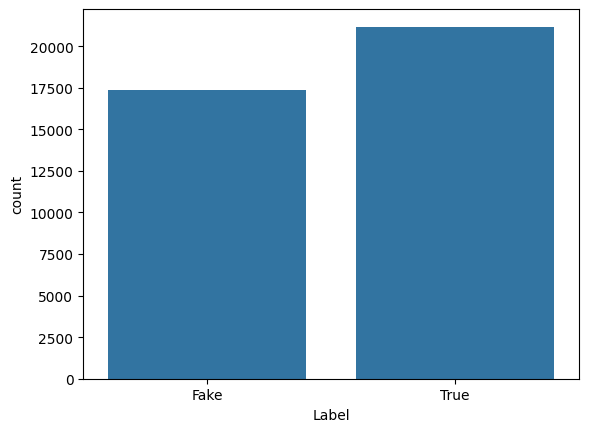

In [6]:
sns.countplot(x="Label", data=df) # Quantidade de classes

**Pré-processamento**

In [7]:
!pip install nltk

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...


[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["title"].apply(preprocess_text)

In [10]:
df.head(5)

,Unnamed: 0,title,subject,date,Label,clean_text,label_number,char_count,word_count,avg_word_length
0,0,Donald Trump Sends Out Embarrassing New Year’...,News,"December 31, 2017",Fake,donald trump sends embarrassing new year eve m...,0,2620,474,5.527426
1,1,Drunk Bragging Trump Staffer Started Russian ...,News,"December 31, 2017",Fake,drunk bragging trump staffer started russian c...,0,1850,304,6.085526
2,2,Sheriff David Clarke Becomes An Internet Joke...,News,"December 30, 2017",Fake,sheriff david clarke becomes internet joke thr...,0,3298,564,5.847518
3,3,Trump Is So Obsessed He Even Has Obama’s Name...,News,"December 29, 2017",Fake,trump obsessed even obamas name coded website ...,0,2462,423,5.820331
4,4,Pope Francis Just Called Out Donald Trump Dur...,News,"December 25, 2017",Fake,pope francis called donald trump christmas speech,0,2292,420,5.457143


<Axes: xlabel='Label', ylabel='count'>

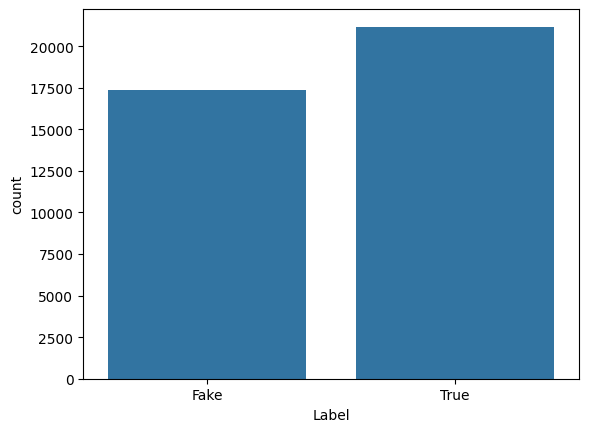

In [11]:
sns.countplot(x="Label", data=df) # validando se mudou as classes

**OVERSAMPLING**

In [12]:
from imblearn.over_sampling import SMOTE

In [13]:
from imblearn.pipeline import Pipeline as imbpipeline #importa o pipeline do imblearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.svm import LinearSVC
from imblearn.over_sampling import SMOTE

X = df['clean_text']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline_smote = imbpipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LinearSVC())
])

pipeline_smote.fit(X_train, y_train)
y_pred_smote = pipeline_smote.predict(X_test)

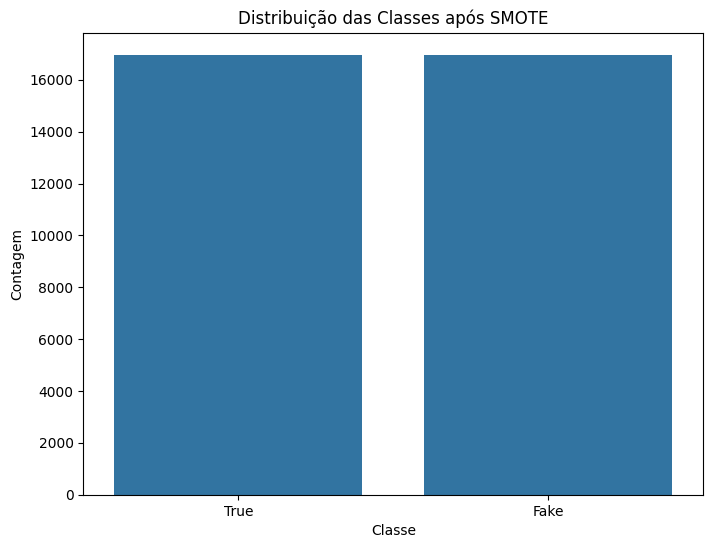

Contagem das classes após SMOTE:
Label
True    16970
Fake    16970
Name: count, dtype: int64


In [14]:
import matplotlib.pyplot as plt # Import the pyplot module from matplotlib
# Obter as classes balanceadas após o SMOTE
y_resampled = pipeline_smote.named_steps['smote'].fit_resample(
    pipeline_smote.named_steps['vect'].fit_transform(X_train), y_train
)[1]

# Contar a distribuição das classes
class_distribution = pd.Series(y_resampled).value_counts()

# Visualizar a distribuição das classes
plt.figure(figsize=(8, 6))
sns.countplot(x=y_resampled)
plt.title('Distribuição das Classes após SMOTE')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.show()

# Imprimir a contagem das classes
print('Contagem das classes após SMOTE:')
print(class_distribution)

**LIME**

In [15]:
# Assuming 'text' is the column name containing the text data and 'sentiment' is the target column
X = df['clean_text']
y = df['Label']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from IPython.display import display
from lime.lime_text import LimeTextExplainer


def predict_proba(texts):
    # LIME espera probabilidades, mas LinearSVC não tem predict_proba.
    # Usamos decision_function e normalizamos para somar 1 (softmax-like).
    scores = pipeline_smote.decision_function(texts)
    # Se for 1D (binary), transforma em 2D
    if len(scores.shape) == 1:
        scores = np.vstack([-scores, scores]).T
    # Softmax para converter scores em "probabilidades"
    exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
    probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)
    return probs

# Solicita ao usuário o número da linha do exemplo
idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

# Predição da classe para o texto selecionado
pred_class_name = pipeline_smote.predict([sample_text])[0]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Real class: {sample_label}")
print(f"Classe predita: {pred_class_name}")

# Criando o explainer
explainer = LimeTextExplainer(class_names=list(pipeline_smote.classes_))

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

Número da linha no X_test: 499
Original text:
party motherland north korea kim herald missile test setback
Real class: True
Classe predita: True


In [18]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")


Palavras mais importantes e seus pesos:
north: 0.0770
korea: 0.0512
setback: 0.0293
kim: -0.0138
party: 0.0125
test: 0.0080
herald: -0.0069
missile: -0.0010
motherland: 0.0010


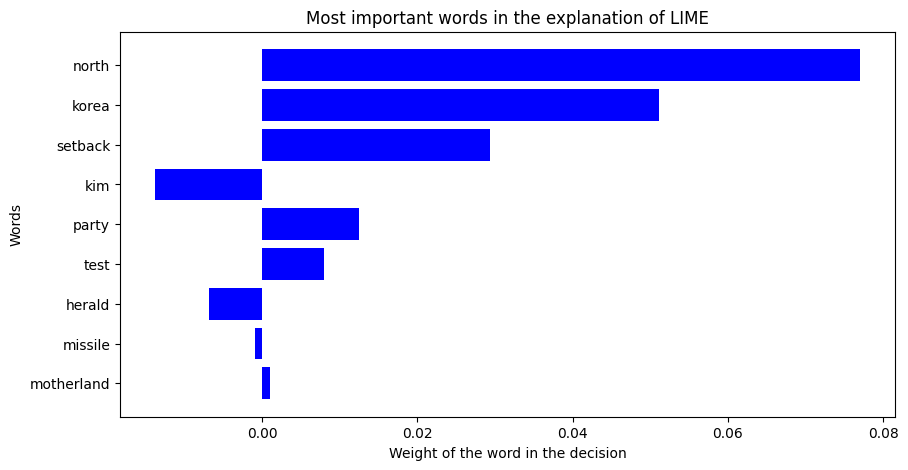

In [19]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [20]:
explanation_list = explanation.as_list()
lime_df = pd.DataFrame(explanation_list, columns=["Word", "Impact"])

# Ordenar por impacto
lime_df = lime_df.sort_values(by="Impact", ascending=False)

display(lime_df.head(20))  # Exibir as 20 palavras mais impactantes

,Word,Impact
0,north,0.076974
1,korea,0.051153
2,setback,0.029313
4,party,0.012487
5,test,0.008020
8,motherland,0.000954
7,missile,-0.000970
6,herald,-0.006905
3,kim,-0.013786


<Figure size 1000x600 with 0 Axes>

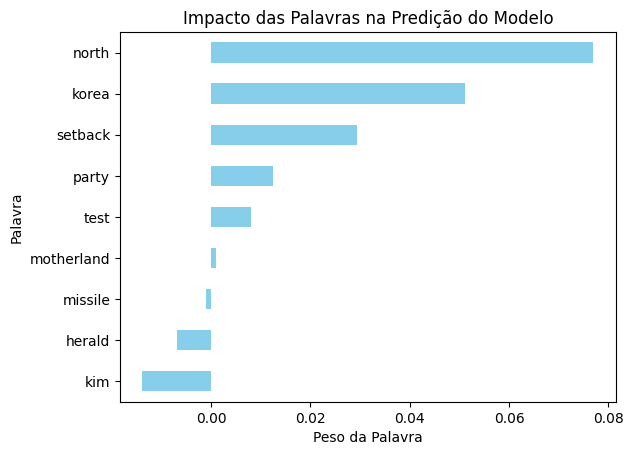

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
lime_df.plot(kind="barh", x="Word", y="Impact", color="skyblue", legend=False)
plt.xlabel("Peso da Palavra")
plt.ylabel("Palavra")
plt.title("Impacto das Palavras na Predição do Modelo")
plt.gca().invert_yaxis()  # Inverte o eixo para as palavras mais importantes ficarem no topo
plt.show()

In [22]:
y_pred = pipeline_smote.predict(X_test)

**Métricas**

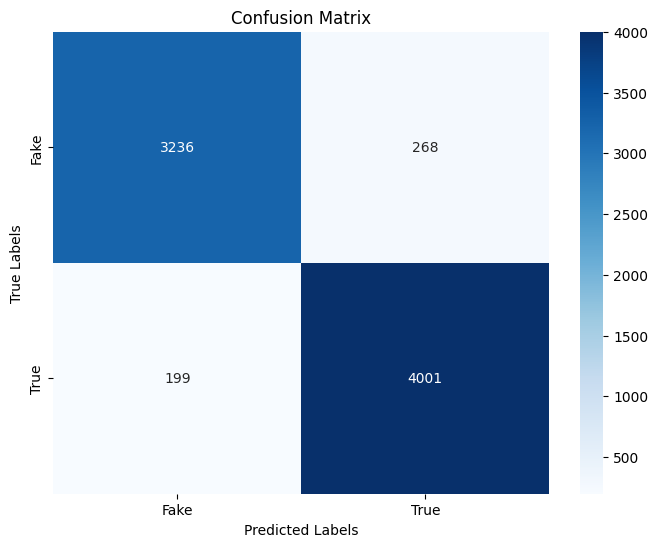

In [23]:
# prompt: matriz de confusão

import matplotlib.pyplot as plt
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=pipeline_smote.classes_, yticklabels=pipeline_smote.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Import necessary metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Usando 'weighted' para classes múltiplas
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.9394
Precisão: 0.9394
Recall: 0.9394
F1-Score: 0.9393


**Attention Vizualization**

In [25]:
#verificando a ordem das classes
print(pipeline_smote.classes_)

['Fake' 'True']


Palavras do exemplo e seus pesos na decisão da classe prevista:
       Feature    Weight
11955    north  1.463454
9843     korea  0.974027
15781  setback  0.509028
12739    party  0.326714
17562     test  0.284605
8261    herald  0.193055
11240  missile  0.158451
9768       kim  0.036331


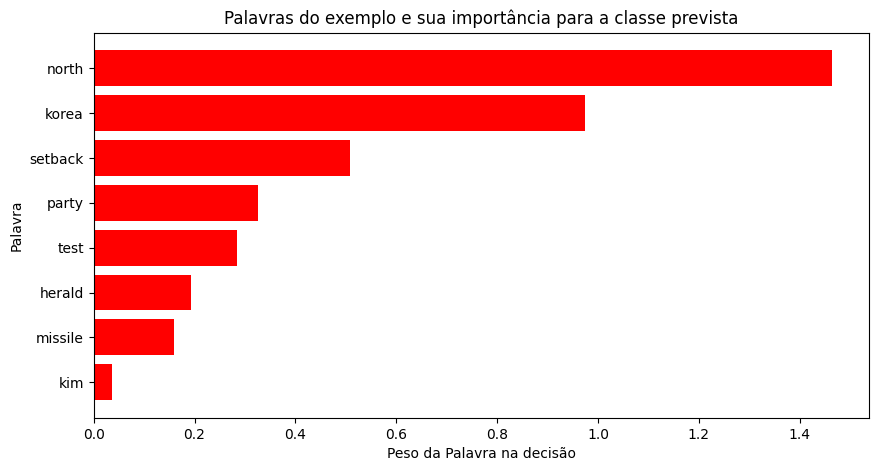

In [26]:
# Obter os nomes das features do CountVectorizer
feature_names = pipeline_smote.named_steps['vect'].get_feature_names_out()

# Obter os coeficientes do SVM para a classe prevista
clf = pipeline_smote.named_steps['clf']
vect = pipeline_smote.named_steps['vect']

# Sempre existe apenas um vetor de pesos no caso binário
pesos = clf.coef_[0]

classe_prevista = pipeline_smote.predict([sample_text])[0]
classes = pipeline_smote.classes_

# Ajustar o sinal para explicar a classe prevista
if classe_prevista == classes[0]:
    pesos = -pesos

# Criar DataFrame com as features e pesos
importancias = pd.DataFrame({'Feature': feature_names, 'Weight': pesos})

# Marcar as palavras do exemplo
#palavras_exemplo = set(sample_text.split())
palavras_exemplo = set(vect.build_analyzer()(sample_text))
importancias['No_Exemplo'] = importancias['Feature'].apply(lambda x: x in palavras_exemplo)

# Visualizar as palavras do exemplo e seus pesos
importancias_exemplo = importancias[importancias['No_Exemplo']].sort_values(by='Weight', ascending=False)

print("Palavras do exemplo e seus pesos na decisão da classe prevista:")
print(importancias_exemplo[['Feature', 'Weight']])

# Plotar as palavras do exemplo
plt.figure(figsize=(10, 5))
plt.barh(importancias_exemplo['Feature'], importancias_exemplo['Weight'], color="red")
plt.xlabel("Peso da Palavra na decisão")
plt.ylabel("Palavra")
plt.title("Palavras do exemplo e sua importância para a classe prevista")
plt.gca().invert_yaxis()
plt.show()

Shapley

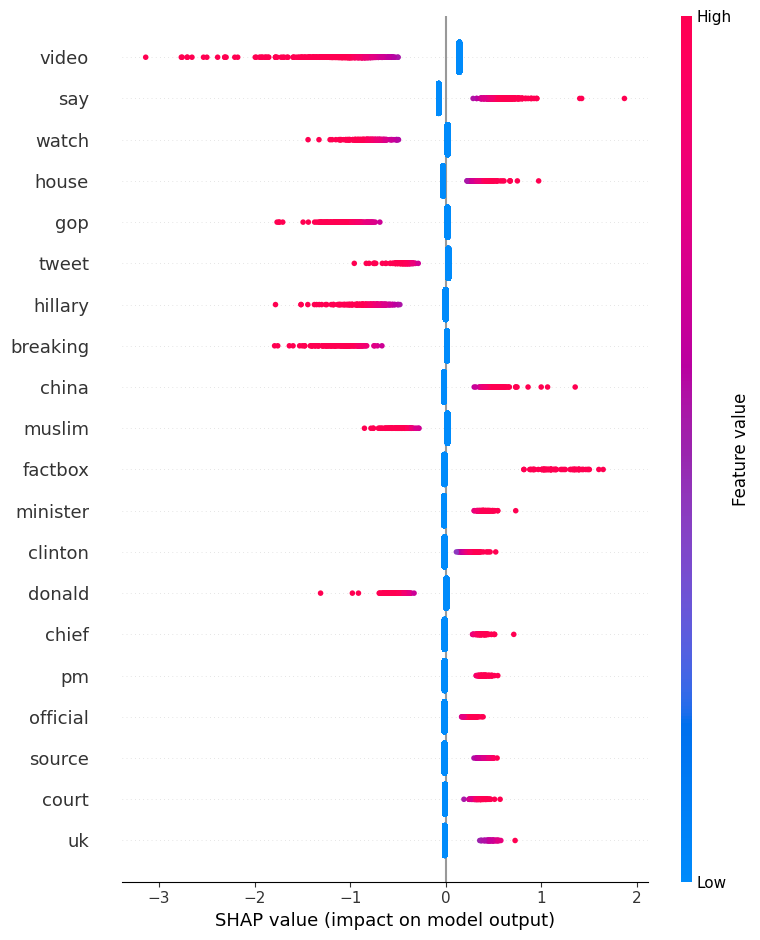

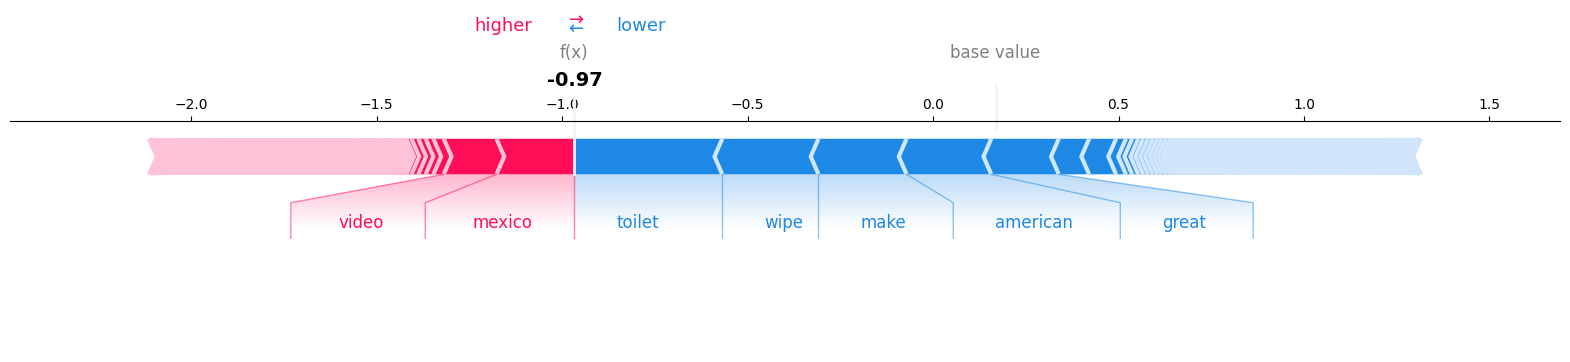

In [34]:
# Transformar os dados usando o pipeline (sem o classificador)
X_train_transformed = pipeline_smote.named_steps['tfidf'].transform(
    pipeline_smote.named_steps['vect'].transform(X_train)
)

X_test_transformed = pipeline_smote.named_steps['tfidf'].transform(
    pipeline_smote.named_steps['vect'].transform(X_test)
)

# Selecionar um subconjunto do treino como background (melhora performance e evita estouro de memória)
background_size = 100
background = X_train_transformed[np.random.choice(X_train_transformed.shape[0], 
                                                  min(background_size, X_train_transformed.shape[0]), 
                                                  replace=False)]

# Criar o explainer para modelo linear
explainer = shap.LinearExplainer(
    pipeline_smote.named_steps['clf'],
    background,
    feature_perturbation="interventional"
)

# Calcular valores SHAP para o conjunto de teste
shap_values = explainer.shap_values(X_test_transformed)

# Obter nomes das features
feature_names = pipeline_smote.named_steps['vect'].get_feature_names_out()

X_test_dense = X_test_transformed.toarray()
feature_names = pipeline_smote.named_steps['vect'].get_feature_names_out()

class_idx = 0  # escolha a classe (0=neg, 1=neu, 2=pos)

# Seleciona a classe no ÚLTIMO eixo
shap_class = shap_values

# Summary plot
shap.summary_plot(
    shap_class,
    X_test_dense,
    feature_names=feature_names
)

# Force plot de uma instância
idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_class[idx],
    feature_names=feature_names,
    matplotlib=True
)


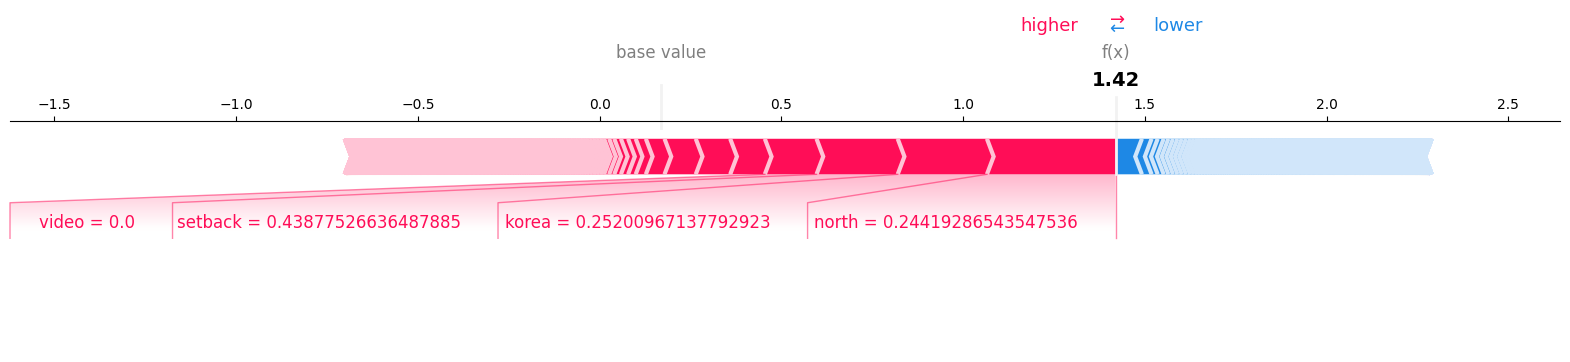

In [36]:
# =========================
# SHAP para mesma instância usada no LIME
# =========================

lime_idx = 499  # <<< coloque aqui o mesmo índice usado no LIME
class_idx = 0  # mesma classe analisada no LIME

X_test_dense = X_test_transformed.toarray()

# Seleciona a classe correta
shap_class = shap_values

# Force plot da mesma instância
shap.force_plot(
    explainer.expected_value,
    shap_class[lime_idx],
    X_test_dense[lime_idx],
    feature_names=feature_names,
    matplotlib=True
)
